--- SECOM Dataset Results ---
Original Features: 590 | Accuracy: 0.8822
PCA Components: 50 | Accuracy: 0.9140


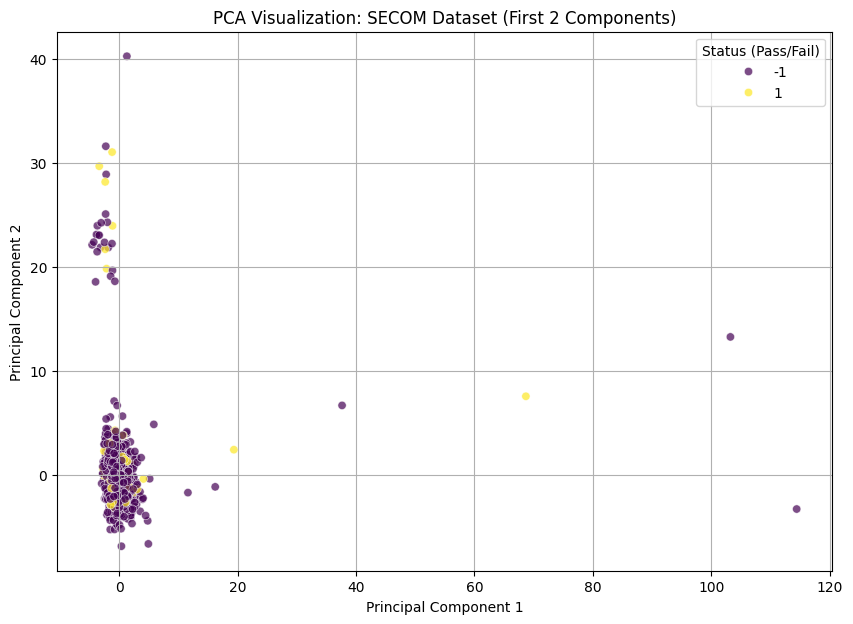

In [3]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


url = "https://archive.ics.uci.edu/ml/machine-learning-databases/secom/secom.data"
labels_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/secom/secom_labels.data"

data = pd.read_csv(url, sep=" ", header=None)
labels = pd.read_csv(labels_url, sep=" ", header=None)[0]


data = data.fillna(data.mean())


scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, labels, test_size=0.2, random_state=42)


model_orig = LogisticRegression(max_iter=1000)
model_orig.fit(X_train, y_train)
acc_orig = accuracy_score(y_test, model_orig.predict(X_test))


pca = PCA(n_components=50)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)


model_pca = LogisticRegression(max_iter=1000)
model_pca.fit(X_train_pca, y_train)
acc_pca = accuracy_score(y_test, model_pca.predict(X_test_pca))

print(f"--- SECOM Dataset Results ---")
print(f"Original Features: {data.shape[1]} | Accuracy: {acc_orig:.4f}")
print(f"PCA Components: 50 | Accuracy: {acc_pca:.4f}")



import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))

sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1], hue=y_train, palette='viridis', alpha=0.7)

plt.title('PCA Visualization: SECOM Dataset (First 2 Components)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Status (Pass/Fail)', loc='upper right')
plt.grid(True)
plt.show()